<a href="https://colab.research.google.com/github/MeherNaaz19/NLP/blob/main/2303A51902_Assignment_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
df=pd.read_csv("/content/Consumer_Complaints.csv")
df.head(25)

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer Complaint,Company Public Response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date Sent to Company,Company Response to Consumer,Timely response?,Consumer disputed?,Complaint ID,Unnamed: 18
0,03-12-2014,Mortgage,Other mortgage,"Loan modification,collection,foreclosure",NaN,NaN,NaN,M&T BANK CORPORATION,MI,48382,NaN,NaN,Referral,03/17/2014,Closed with explanation,Yes,No,759217.0,NaN
1,10-01-2016,Credit reporting,NaN,Incorrect information on credit report,Account status,I have outdated information on my credit repor...,Company has responded to the consumer and the ...,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",AL,352XX,NaN,Consent provided,Web,10-05-2016,Closed with explanation,Yes,No,2141773.0,NaN
2,10/17/2016,Consumer Loan,Vehicle loan,Managing the loan or lease,NaN,I purchased a new car on XXXX XXXX. The car de...,NaN,"CITIZENS FINANCIAL GROUP, INC.",PA,177XX,Older American,Consent provided,Web,10/20/2016,Closed with explanation,Yes,No,2163100.0,NaN
3,06-08-2014,Credit card,NaN,Bankruptcy,NaN,NaN,NaN,AMERICAN EXPRESS COMPANY,ID,83854,Older American,NaN,Web,06-10-2014,Closed with explanation,Yes,Yes,885638.0,NaN
4,09/13/2014,Debt collection,Credit card,Communication tactics,Frequent or repeated calls,NaN,NaN,"CITIBANK, N.A.",VA,23233,NaN,NaN,Web,09/13/2014,Closed with explanation,Yes,Yes,1027760.0,NaN
5,11/13/2013,Mortgage,Conventional adjustable mortgage (ARM),"Loan servicing, payments, escrow account",NaN,NaN,NaN,U.S. BANCORP,MN,48322,NaN,NaN,Phone,11/20/2013,Closed with monetary relief,Yes,No,596562.0,NaN
6,06/16/2015,Debt collection,Medical,Improper contact or sharing of info,Contacted employer after asked not to,NaN,Company believes it acted appropriately as aut...,California Accounts Service,CA,92111,NaN,Consent not provided,Web,06/19/2015,Closed with explanation,Yes,No,1422680.0,NaN
7,06/15/2015,Credit reporting,NaN,Credit reporting company's investigation,Inadequate help over the phone,An account on my credit report has a mistaken ...,Company chooses not to provide a public response,Experian Information Solutions Inc.,VA,224XX,NaN,Consent provided,Web,06/15/2015,Closed with explanation,Yes,No,1420702.0,NaN
8,11/13/2015,Mortgage,Other mortgage,"Loan modification,collection,foreclosure",NaN,NaN,Company believes it acted appropriately as aut...,"Aldridge Pite, LLP",CA,93101,NaN,NaN,Referral,12-10-2015,Closed with explanation,Yes,Yes,1654890.0,NaN
9,10/21/2014,Mortgage,Conventional fixed mortgage,"Loan modification,collection,foreclosure",NaN,NaN,NaN,OCWEN LOAN SERVICING LLC,FL,32714,Older American,NaN,Web,10/21/2014,Closed with explanation,Yes,No,1079567.0,NaN


In [ ]:
column_to_print = 'Consumer Complaint'
print(f"First 25 entries in the '{column_to_print}' column:")
display(df[column_to_print].head(25))

First 25 entries in the 'Consumer Complaint' column:


,Consumer Complaint
0,NaN
1,I have outdated information on my credit repor...
2,I purchased a new car on XXXX XXXX. The car de...
3,NaN
4,NaN
5,NaN
6,NaN
7,An account on my credit report has a mistaken ...
8,NaN
9,NaN


In [ ]:
print("Number of characters:",len(df.iloc[1]))

Number of characters: 19


In [ ]:
f=df['Consumer Complaint'].iloc[1]
print(f)

I have outdated information on my credit report that I have previously disputed that has yet to be removed this information is more then seven years old and does not meet credit reporting requirements


In [ ]:
import spacy

In [ ]:
nlp=spacy.load('en_core_web_sm')
doc=nlp(f)
for i in doc:
    print(i,"=",i.pos_)

I = PRON
have = VERB
outdated = VERB
information = NOUN
on = ADP
my = PRON
credit = NOUN
report = NOUN
that = PRON
I = PRON
have = AUX
previously = ADV
disputed = VERB
that = PRON
has = VERB
yet = ADV
to = PART
be = AUX
removed = VERB
this = DET
information = NOUN
is = AUX
more = ADV
then = ADV
seven = NUM
years = NOUN
old = ADJ
and = CCONJ
does = AUX
not = PART
meet = VERB
credit = NOUN
reporting = NOUN
requirements = NOUN


In [ ]:
pos_counts = {
"NOUN": 0,
"PRON": 0,
"VERB": 0,
"ADV": 0
}
for i in doc:
      if i.pos_ in pos_counts:
              pos_counts[i.pos_] +=1
for pos, count in pos_counts.items():
      print(f"Number of {pos.lower()}s: {count}")

Number of nouns: 8
Number of prons: 5
Number of verbs: 6
Number of advs: 4


In [ ]:
print("Verbs and Adjectives in the text:")
for i in doc:
    if i.pos_ in ["VERB","ADJ"]:
        print(i.text,"=",i.pos_)

Verbs and Adjectives in the text:
have = VERB
outdated = VERB
disputed = VERB
has = VERB
removed = VERB
old = ADJ
meet = VERB


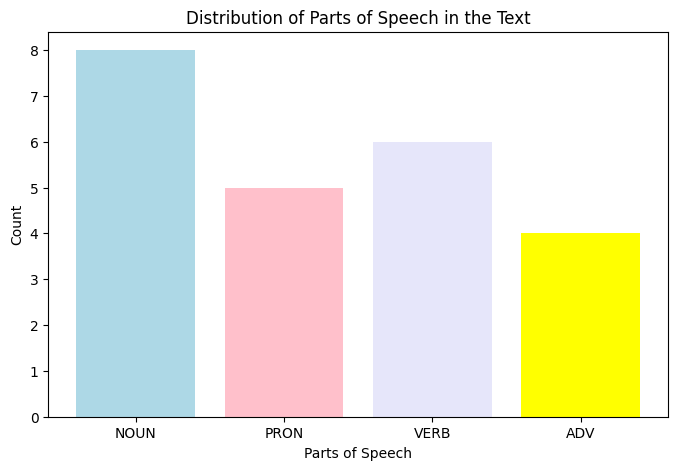

In [ ]:
import matplotlib.pyplot as plt
pos_labels=list(pos_counts.keys())
counts=list(pos_counts.values())
plt.figure(figsize=(8,5))
plt.bar(pos_labels, counts, color=['lightblue','pink','lavender','yellow'])
plt.xlabel("Parts of Speech")
plt.ylabel("Count")
plt.title("Distribution of Parts of Speech in the Text")
plt.show()

In [ ]:
import re

In [ ]:
text = """
My phone number is 1234567890 and my email is test@domain.com
Visit https://example.com for more info!!!
HELLO!!! This is SOOOOO exciting :))
Contact us at info@company.org or call ‪+91 98765-43210‬
Python's regex is very useful!!!  #Coding #Fun
"""

In [ ]:
phone_pattern=r'\b(?:\+?\d{1,3}[-\s]?)?(?:\d{10}|\d{3,5}[-\s]?\d{5,7})\b'
phones = re.findall(phone_pattern, text)
print("Phone Numbers Found:", phones)

Phone Numbers Found: ['1234567890', '91 98765-43210']


In [ ]:
no_phones=re.sub(phone_pattern, '', text)
no_emails=re.sub(r'\b[\w\.-]+@[\w\.-]+\.\w+\b', '',no_phones)
no_urls=re.sub(r'https?://\S+|www\.\S+', '',no_emails)
cleaned_text=re.sub(r'[^A-Za-z0-9\s]', '',no_urls)
cleaned_text = re.sub(r'\s+', ' ',cleaned_text).strip()
print("\nCleaned Text:\n",cleaned_text)


Cleaned Text:
 My phone number is and my email is Visit for more info HELLO This is SOOOOO exciting Contact us at or call Pythons regex is very useful Coding Fun
